## Modelo multivariado Normal

Este cuaderno explica el proceso multivariado cuando se tiene una distribución normal y se busca una distribución posterior usando una distribución semiconjugada previa conocida como la distribución Wishart. La distribución normal univariada es un componente de esta distribución y la mayor ventaja de la forma multivariada es que las variables aleatorias se pueden evaluar de forma conjunta con ayuda de la matriz de varianza y covarianza.

Primero se evalua el proceso cuando la matriz de varianza y covarianza es conocida y luego se realiza el mismo proceso obteniendo esta matriz por separado

### Caso en el que se conoce la matriz de varianza y covarianza.

En este caso se obtiene un proceso conjugado debido a que la distribución prior es una normal multivariada con hiperparámetros $\mu_{0}$ y $\Lambda_{0}$ en este caso $p(\theta) \sim MVN(\mu_{0},\Lambda_{0})$


La distribución Likelihood con vectores $\mathbf{\theta}$ y matriz de covarianza $\Sigma$ es igual a:

$$p(\mathbf{y} \mid \mathbf{\theta},\Sigma) \sim MVN(\mathbf{\theta},\Sigma)$$

Donde  $\mathbf{y}$ y $\mathbf{\theta}$ son dos vectores y  $\Sigma$ es una matriz de varianza y covarianza.

 $\mathbf{y}=\begin{pmatrix}
  y_{1} \\
  y_{2} \\
  \vdots  \\
  y_{n}
 \end{pmatrix}$

 $\mathbf{\theta}=\begin{pmatrix}
  \theta_{1} \\
  \theta_{2} \\
  \vdots  \\
  \theta_{n}
 \end{pmatrix}$



$\Sigma = \begin{pmatrix}
  \sigma_{1}^{2} & \sigma_{1,2} & \cdots & \sigma_{1,n} \\
  \sigma_{2,1} & \sigma^{2}_{2} & \cdots & \sigma_{2,n} \\
  \vdots  & \vdots  & \ddots & \vdots  \\
  \sigma_{n,1} & \sigma_{n,2} & \cdots & \sigma^{2}_{n} 
 \end{pmatrix}$
 
 
Por lo tanto la distribución previa se puede simplificar de la siguiente forma:


$$ p(\mathbf{\theta})=(2\pi)^{-n/2}\mid \Lambda_{0}\mid^{-1/2} exp\{-1/2(\mathbf{\theta}-\mu_{0})^{T} \Lambda_{0}^{-1} (\mathbf{\theta}-\mu_{0})\}$$

$$p(\mathbf{\theta})\propto  exp\{-1/2\mathbf{\theta}^{T} \Lambda_{0}^{-1}\mathbf{\theta}+ \mathbf{\theta}^{T}\Lambda_{0}^{-1} \mu_{0})\}$$


$$p(\mathbf{\theta})= exp\{-1/2\mathbf{\theta}^{T} \mathbf{A}_{0}\mathbf{\theta}+ \mathbf{\theta}^{T} \mathbf{b}_{0})\}$$
 
 
Donde $\mathbf{A}_{0}= \Lambda_{0}^{-1}$ y $\mathbf{b}_{0}=\Lambda_{0}^{-1} \mu_{0}$

Usando el mismo proceso del curso se obtiene la distribución likelihood 

$$p(\mathbf{y}_{1},...,\mathbf{y}_{n} \mid \mathbf{\theta},\Sigma)=\prod_{i=1}^{n}(2\pi)^{-p/2}\mid \Sigma \mid^{-1/2}exp\{-(\mathbf{y}-\mathbf{\theta})^{T} \Sigma^{-1}(\mathbf{y}-\mathbf{\theta})/2\}$$

$$p(\mathbf{y}_{1},...,\mathbf{y}_{n} \mid \mathbf{\theta},\Sigma)=(2\pi)^{-np/2}\mid \Sigma \mid^{-n/2}exp\{-1/2\sum_{i=1}^{n}(\mathbf{y}_{i}-\mathbf{\theta})^{T} \Sigma^{-1}(\mathbf{y}_{i}-\mathbf{\theta})\}$$

$$p(\mathbf{y}_{1},...,\mathbf{y}_{n} \mid \mathbf{\theta},\Sigma)\propto exp\{-1/2 \mathbf{\theta}^{T}  \mathbf{A}_{1} \mathbf{\theta}+ \mathbf{\theta}^{T} \mathbf{b}_{1}\}$$

Donde $ \mathbf{A}_{1}=n\sum^{-1}$, $\mathbf{b}_{1}=n\sum^{-1}\overline{\mathbf{y}}$, siendo $\overline{\mathbf{y}}$ un vector de promedios para cada lista de observaciones.


La distribución posterior es el resultado de la multiplicación:


$$p(\mathbf{\theta \mid \mathbf{y}_{1},...,\mathbf{y}_{n}\Sigma}\propto  exp\{-1/2\mathbf{\theta}^{T} \mathbf{A}_{0}\mathbf{\theta}+ \mathbf{\theta}^{T} \mathbf{b}_{0})\}\times exp\{-1/2 \mathbf{\theta}^{T}  \mathbf{A}_{1} \mathbf{\theta}+ \mathbf{\theta}^{T} \mathbf{b}_{1}\} $$

$$ =exp\{-1/2 \mathbf{\theta}^{T} \mathbf{A}_{n} \mathbf{\theta}+ \mathbf{\theta}^{T}\mathbf{b}_{n}\}$$

Donde $ \mathbf{A}_{n}= \mathbf{A}_{0}+ \mathbf{A}_{1}$ y $\mathbf{b}_{n}=\mathbf{b}_{0}+\mathbf{b}_{1}$.


Los parámetros de la distribución posterior de $\mathbf{\theta}$ cuando esta tiene una distribución multivariada son:

$$Cov[\mathbf{\theta}\mid \mathbf{y}_{1},...,\mathbf{y}_{n}, \Sigma]=\Lambda_{n}=(\Lambda_{0}^{-1}+n\Sigma^{-1})^{-1}$$


$$E[\mathbf{\theta}\mid \mathbf{y}_{1},...,\mathbf{y}_{n}, \Sigma]=\mathbf{\mu}_{n}=(\Lambda_{0}^{-1}+n\Sigma^{-1})^{-1}(\Lambda_{0}^{-1}\mathbf{\mu}_{0}+n\Sigma^{-1}\overline{\mathbf{y}})$$




El primer ejemplo es una representación de una distribución normal multivariada en donde se analiza de forma conjunta un vector $x$ y $y$ cada uno tiene su propia media y varianza formando entre los dos un vector y una matriz con covarianza cero.

In [5]:
import numpy as np
import pandas as pd
import io
import requests
import matplotlib.pyplot as plt
import math
import seaborn as sns
import datetime
from fredapi import Fred
%matplotlib inline
import pymc as pm
from scipy.stats import norm
from IPython.core.pylabtools import figsize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [6]:
!pip3 install fredapi


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip


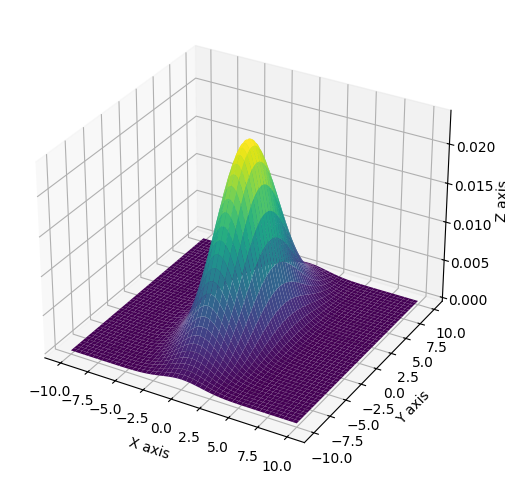

In [7]:

figsize(18.5,6)
#Parameters to set
mu_x = 0
variance_x = 3

mu_y = 0
variance_y = 15

#Create grid and multivariate normal
x = np.linspace(-10,10,500)
y = np.linspace(-10,10,500)
X, Y = np.meshgrid(x,y)
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X; pos[:, :, 1] = Y
rv = multivariate_normal([mu_x, mu_y], [[variance_x, 0], [0, variance_y]])

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, rv.pdf(pos), cmap='viridis', linewidth=0)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()



### Caso de varianza desconocida

En el modelo univariado existia el caso en el que la varianza poblacional es desconocida y tiene que ser estimada para poder obtener el parámetro $\theta$. Para estimar la varianza, se usaba una distribución inverse gamma. Para la versión multivariada la distribución Wishart permite estimar la matriz $\Sigma$ con la que después se obtiene el parámetro $\mathbf{\theta}$.



Generar muestras a partir de una distribución de Wishart es análogo a muestrear un conjunto de
variables de una distribución normal multivariante y el cálculo de la empírica
matriz de covarianza de las muestras. Más específicamente, con parámetros $\nu_0 \in
\mathbb{Z}^+$ y $\Phi_0$ (a $p \times p$ matriz de covarianza),

1. Muestra $z_1, \dots, z_{\nu_0} \sim \mathcal{N}(\boldsymbol{0}, \Phi_0)$
2. Calcular  $\boldsymbol{Z}^T \boldsymbol{Z} = \sum_{i = 1}^{\nu_0} z_i z_i^T$

Por lo tanto, $\boldsymbol{Z}_1^T \boldsymbol{Z}_1, \dots, \boldsymbol{Z}_S^T \boldsymbol{Z} \sim \text{Wishart}(\nu_0, \Phi_0)$.

Las propiedades de las muestras de una distribución  Wishart se presentan a continuación:

- Si $\nu_0 > p$ entonces $\boldsymbol{Z}^T\boldsymbol{Z}$ es positiva.
- $\boldsymbol{Z}^T\boldsymbol{Z}$ es simétrica.
- $\mathbb{E}(\boldsymbol{Z}^T\boldsymbol{Z}) = \nu_0 \Phi_0$

La distribución Wishart no es la conjugada previa de la varianza para el multivariante
Normal; más bien, al igual que con el caso de  la distribución gamma en la forma univariada, se usa la distribución  inverse Wishart. La muestra de una distribución inverse  Wishart se calcula como $\Sigma^{(s)} = (\boldsymbol{Z}^{(s)T} \boldsymbol{Z}^{(s)})^{-1}$

En donde la muestra de una inverse Wishart cambia de $\Phi_0$ a $\mathbf{S}_0^{-1}$:

- $\mathbb{E}(\Sigma^{-1}) = \nu_0 \mathbf{S}_0^{-1}$. 
- $\mathbb{E}(\Sigma) = \frac{1}{\nu_0 - p - 1} \mathbf{S}_0$.

### Parámetros iniciales 

Especificar parámetros es algo interesante para la inverse Wishart porque
hay muchos de ellos; necesitamos especificar la matriz de covarianza completa. Tener una expectativa previa de una matriz de covarianza $\Sigma_0$, permite centrar
la distribución previa de dos formas sugeridas:

- Tener un hiperparámetro $\nu_0$ largo y tener  $\mathbf{S}_0 = (\nu_0 - p - 1) \Sigma_0$, que permita calcular el valor esperado de la covarianza
$\mathbb{E}(\Sigma) = \frac{\nu_0 - p - 1}{\nu_0 - p - 1}\Sigma_0 = \Sigma_0$
esto permite concentrar los parámetros de la distribución prior alrededor de $\Sigma_0$;
- Tener un hiperparámetro $\nu_0 = p + 2$ y tener $\mathbf{S}_0 = \Sigma_0$, para calcular
$\mathbb{E}(\Sigma) = \frac{1}{p + 2 - p - 1}\Sigma_0 = \Sigma_0$.



### Full conditional distribution 

Un matriz de covarianza que depende de las observaciones y $\theta$ se distribuye $\Sigma \mid \boldsymbol{y}_1, \dots, \boldsymbol{y}_n, \boldsymbol{\theta}$

La covarianza se calcula  $\Sigma \sim \text{inverse-Wishart}(\nu_0, \mathbf{S}_0^{-1})$,

\begin{align}
p(\Sigma) \propto | \Sigma |^{-(\nu_0 + p + 1) / 2} \times \exp\left(-\text{tr}(\mathbf{S}_0 \Sigma^{-1})  / 2\right)
\end{align}

La distribución likelihood se puede simplificar usando álgebra lineal

\begin{align}
p(\mathbf{y}_1, \dots, \mathbf{y}_n \mid \boldsymbol{\theta}, \Sigma) &= (2\pi)^{-np/2} | \Sigma |^{-n/2} \exp \left( - \sum_{i = 1}^n (\boldsymbol{y}_i - \boldsymbol{\theta})^T \Sigma^{-1} (\boldsymbol{y}_i - \boldsymbol{\theta}) / 2 \right)
\end{align}


\begin{align}
\sum_{i = 1}^n (\boldsymbol{y}_i - \boldsymbol{\theta})^T \Sigma^{-1} (\boldsymbol{y}_i - \boldsymbol{\theta}) &= \text{tr}\left( \left(\sum_{i = 1}^n (\boldsymbol{y}_i - \boldsymbol{\theta}) (\boldsymbol{y}_i - \boldsymbol{\theta})^T \right) \Sigma^{-1} \right)
\text{tr}\left( \mathbf{S}_{\theta} \Sigma^{-1} \right)
\end{align}

Donde $\mathbf{S}_{\theta} = \sum_{i = 1}^n (\boldsymbol{y}_i -
\boldsymbol{\theta}) (\boldsymbol{y}_i - \boldsymbol{\theta})^T$ el el residuo de la suma de los cuadrados de la matriz  $\boldsymbol{y}_1, \dots,
\boldsymbol{y}_n$. 

El resultado es:

\begin{align}
p(\mathbf{y}_1, \dots, \mathbf{y}_n \mid \boldsymbol{\theta}, \Sigma) &= (2\pi)^{-np/2} | \Sigma |^{-n/2} \exp \left( - \text{tr}(\mathbf{S}_{\theta} \Sigma^{-1})  / 2 \right)
\end{align}

Usando la distribución previa de $\Sigma$ y la distribución likelihood se obtiene la full conditional distribución:

\begin{align}
p(\Sigma \mid \boldsymbol{y}_1, \dots, \boldsymbol{y}_n, \boldsymbol{\theta}) &\propto p(\Sigma) \times p(\boldsymbol{y}_1, \dots, \boldsymbol{y}_n \mid \boldsymbol{\theta}, \Sigma) \\
&\propto \left[ | \Sigma |^{-(\nu_0 + p + 1) / 2} \times \exp\left(-\text{tr}(\mathbf{S}_0 \Sigma^{-1})  / 2\right) \right] \times
\left[ | \Sigma |^{-n/2} \exp \left( - \text{tr}(\mathbf{S}_{\theta} \Sigma^{-1})  / 2 \right) \right] \\
&=  | \Sigma |^{-(\nu_0 + n + p + 1) / 2} \exp \left( -\text{tr}(\left( \mathbf{S}_0 + \mathbf{S}_{\theta} \right) \Sigma^{-1}) / 2 \right) \\
&\propto \text{dinverse-Wishart}\left(\nu_0 + n, \left[\mathbf{S}_0 + \mathbf{S}_{\theta} \right]^{-1} \right) \\
&= \text{dinverse-Wishart}\left(\nu_n, \mathbf{S}_n^{-1} \right)
\end{align}

Donde $\nu_n = \nu_0 + n$ and $\mathbf{S}_n = \mathbf{S}_0 + \mathbf{S}_{\theta}$.



### (Semiconjugate) prior

Finalmente para concluir esta seeción, se pueden ver los parámetros previos para calcular el parámetro $\theta$ cuando no se conoce la varianza.

- Se debe tener $\mathbf{S}_0$ para la distribución inverse-Wishart
- $\nu_0$ para la distribución inverse-Wishart
    - Un muestra previa que permita estimar *variance* observada.
- $\boldsymbol{mu}_0$ para una distribución multivariada normal 
- $\Lambda_0$ para una distribución multivariada normal ccomo un hiperparámetro inicial de la covarianza de la población.



### Posterior

Los parámetros de la distribución posterior son:

- $\mathbf{S}_n = \mathbf{S}_0 + \mathbf{S}_{\theta}$, donde $\mathbf{S}_{\theta}$ es el residuo de la suma de los cuadrados de la matriz.
- $\nu_n = \nu_0 + n$
- $\mu_n = (\Lambda_0^{-1} + n\Sigma^{-1})^{-1} (\Lambda_0 \boldsymbol{\mu}_0 + n\Sigma^{-1}\bar{\boldsymbol{y}}) = \Lambda_n (\Lambda_0^{-1}\boldsymbol{\mu}_0 + n\Sigma^{-1}\bar{\boldsymbol{y}})$
- $\Lambda_n = (\Lambda_0^{-1} + n\Sigma^{-1})^{-1}$

En el siguiente ejemplo se puede ver la simetría de la distribución Wishart en la matriz de varianza y covarianza resultado del proceso de simulación.

In [8]:
## rwishart for pymc    

def rwishart(nu, S):    
    dim = S.shape[0]
    chol = np.linalg.cholesky(S)
    foo = np.zeros((dim,dim))
    for i in range(dim):
        for j in range(i+1):
            if i == j:
                foo[i,j] = np.sqrt(chi2.rvs(nu-(i+1)+1))
            else:
                foo[i,j]  = norm.rvs(loc=0, scale=1)
    return np.dot(chol, np.dot(foo, np.dot(foo.T, chol.T)))

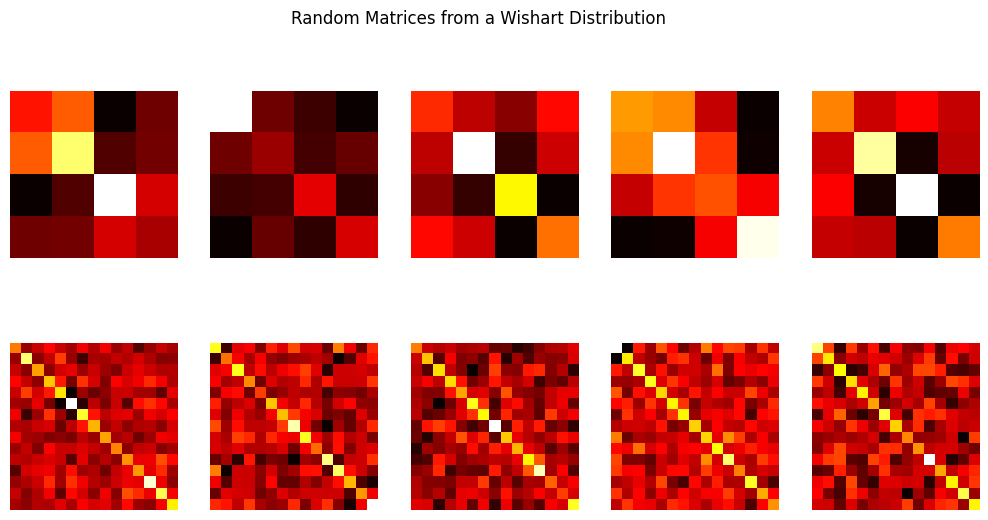

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wishart

# Set the figure size
plt.figure(figsize=(12.5, 6))

# First set of plots
n = 4
hyperparameter = np.eye(n)
for i in range(5):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(wishart.rvs(df=n + 1, scale=hyperparameter, size=1), interpolation="none", cmap=plt.cm.hot)
    ax.axis("off")

# Second set of plots
n = 15
hyperparameter = 10 * np.eye(n)
for i in range(5, 10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(wishart.rvs(df=n + 1, scale=hyperparameter, size=1), interpolation="none", cmap=plt.cm.hot)
    ax.axis("off")

# General title
plt.suptitle("Random Matrices from a Wishart Distribution")

# Show the plots
plt.show()



## Parámetros de un instrumento financiero.

Una acción es un instrumento financiero que da al poseedor una participación sobre la empresa que las emite. Cuando estas se negocian de forma continua se pueden encontrar en mercados organizados como la bolsa de New York o la bolsa de valores de Colombia. Uno de los principales desafios de los inversionistas es tratar de predecir los posibles cambios en el precio. Sin embargo, cuando se desea modelar este tipo de cambios, usualmente se trabaja con la variabilidad del precio a los que se les conoce como retornos. Los retornos se distribuyen de forma normal con media $\mu$ y varianza $\sigma^{2}$ $r_{t}\sim N(\mu,\sigma^{2})$ son una variable continua y permiten calcular el crecimiento o decrecimiento promedio del precio de una acción.

Otro factor que es importante analizar, es que los precios de las acciones no son independientes del entorno económico y son el resultado de los movimientos constantes de los mercados financieros. Esto quiere decir que los rendimientos de una acción están relacionados con los rendimientos de otras acciones, por lo tanto, los cambios en el precio de una acción pueden estar relacionados con los cambios en el precio de otra acción. 

Lo anterior implica que si bien se puede analizar los cambios del precio de una acción de forma individual, un análisis conjunto puede ofrecer otra perspectiva de como los retornos de estos instrumentos financieros cambian cuando el entorno económico financiero es diferente.

En este ejercicio se estimará la media de los retornos de forma conjunta en donde la relación entre las acciones se refleja en la matriz de covarianza $\Sigma$

El proceso se realiza de la siguiente forma:

1- Se descargan los precios directamente desde internet.

2- Se calculan los rendimientos a partir del precio de cierre de cada acción.

3- Se hace un análisis gráfico y descriptivo de los retornos.

4- Se establecen los hiperparámetros de la varianza y la media de los retornos.

5- Se usa la inverse wishart para modelar la covarianza.

6- Se modela el vector de promedios de los retornos usando los resultados de la distribución inverse Wishart

7- Se gráfica la distribución de los parámetros $\theta$ de cada uno de los rendimientos.

8- Se genera la matriz de correlaciones para ver la relación entre los rendimientos de las acciones.




In [10]:
start = datetime.datetime(2015, 1, 1)
end = datetime.datetime(2021,9,12)

In [28]:
import yfinance as yf
import datetime

# Define the start and end dates
start = datetime.datetime(2022, 1, 1)
end = datetime.datetime(2023, 6, 30)

# Fetch data for Boeing (BA)
ba = yf.download('BA', start, end)


# Fetch data for Facebook (FB)
aapl = yf.download('AAPL', start, end)


# Fetch data for JPMorgan Chase (JPM)
jpm = yf.download('JPM', start, end)


# Fetch data for Coca-Cola (KO)
ko = yf.download('KO', start, end)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [29]:
close=pd.concat([ba['Close'], aapl['Close'],jpm['Close'],ko['Close']], axis=1)
close.columns = ['BA', 'AAPL','JPM','KO']
close.tail()

,BA,AAPL,JPM,KO
Date,,,,
2023-06-23,205.410004,185.071793,133.013199,58.453358
2023-06-26,205.580002,183.673981,133.338898,58.472462
2023-06-27,209.429993,186.439911,133.348480,58.348297
2023-06-28,210.720001,187.619659,132.764114,57.803875
2023-06-29,211.830002,187.956741,137.400665,57.326321


## Calculamos los Retornos

$ r_t = \frac{p_t}{p_{t-1}} -1$

In [30]:
n_observations=250
stocks = ["BA", "AAPL", "JPM", "KO"]
stock_closes = close
stock_returns = stock_closes.pct_change()[1:][-n_observations:]

stock_returns=pd.DataFrame(stock_returns)



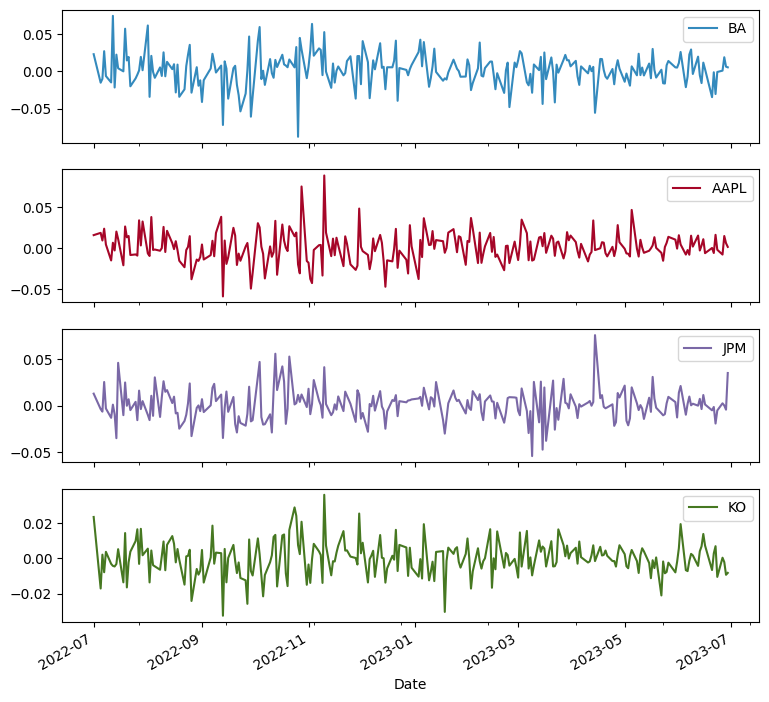

In [31]:
figsize(12.5,3)
colors = ["#348ABD", "#A60628", "#7A68A6", "#467821"]
stock_returns.plot(subplots=True, figsize=(9, 9),color=colors)
plt.legend(loc='best')

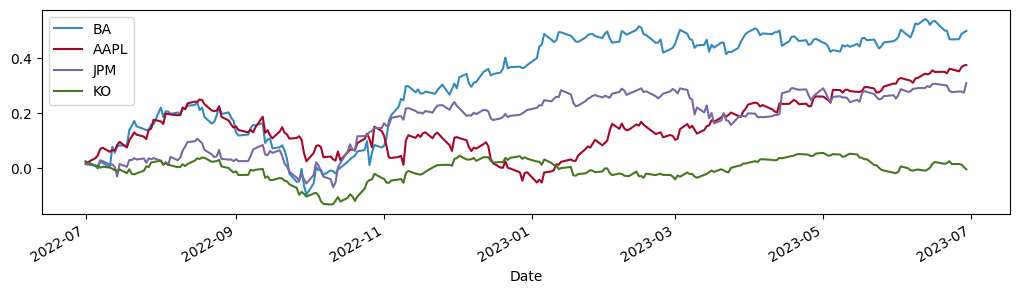

In [32]:
figsize(12.5,3)
cumretornos=stock_returns.cumsum(axis = 0)
colors = ["#348ABD", "#A60628", "#7A68A6", "#467821"]
cumretornos.plot(color=colors)
plt.legend(loc='best')

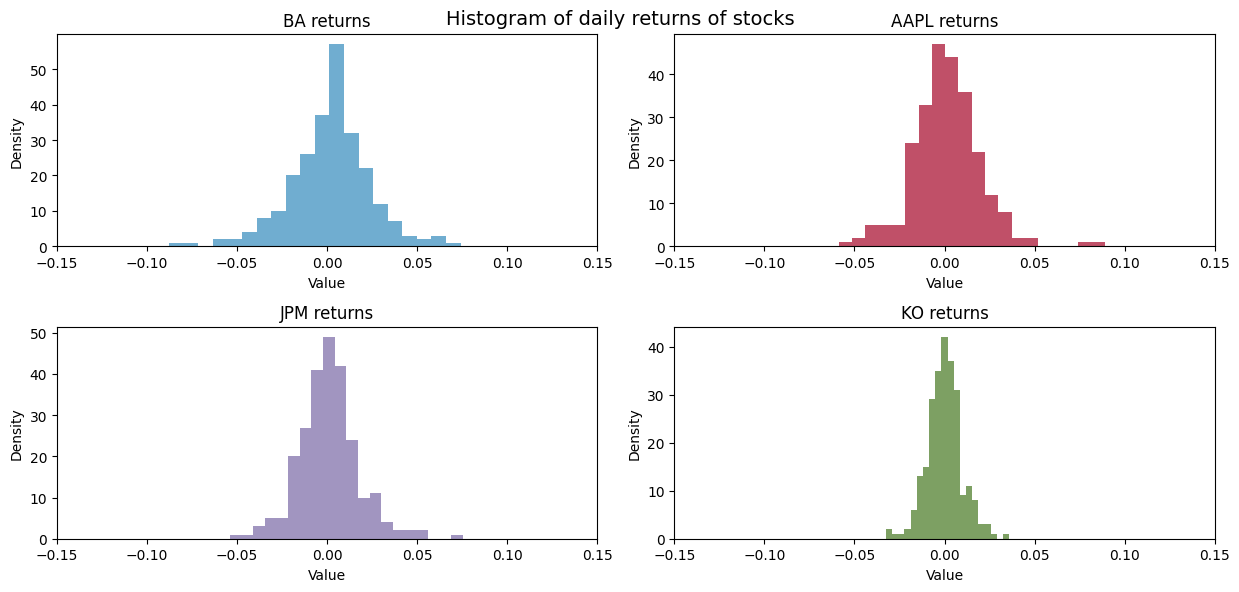

In [33]:
figsize(12.5,6)

returns = np.zeros((n_observations,4))

for i, (_stock,_returns) in enumerate(stock_returns.items()):
    returns[:,i] = _returns
    plt.subplot(2,2,i+1)
    plt.hist( _returns, bins=20, histtype="stepfilled",color=colors[i], alpha=0.7)
    plt.title(_stock + " returns")
    plt.xlim(-0.15, 0.15)
    plt.xlabel('Value')
    plt.ylabel('Density')

plt.tight_layout()
plt.suptitle("Histogram of daily returns of stocks", size=14);

In [34]:
descriptivas=stock_returns.describe()
descriptivas

,BA,AAPL,JPM,KO
count,250.000000,250.000000,250.000000,250.000000
mean,0.002003,0.001504,0.001239,-0.000023
std,0.022389,0.018623,0.016746,0.009729
min,-0.087692,-0.058680,-0.054137,-0.032480
25%,-0.009339,-0.009241,-0.008464,-0.005684
50%,0.003538,0.000697,0.001290,0.000080
75%,0.014566,0.012085,0.009506,0.005419
max,0.074166,0.088975,0.075510,0.035903


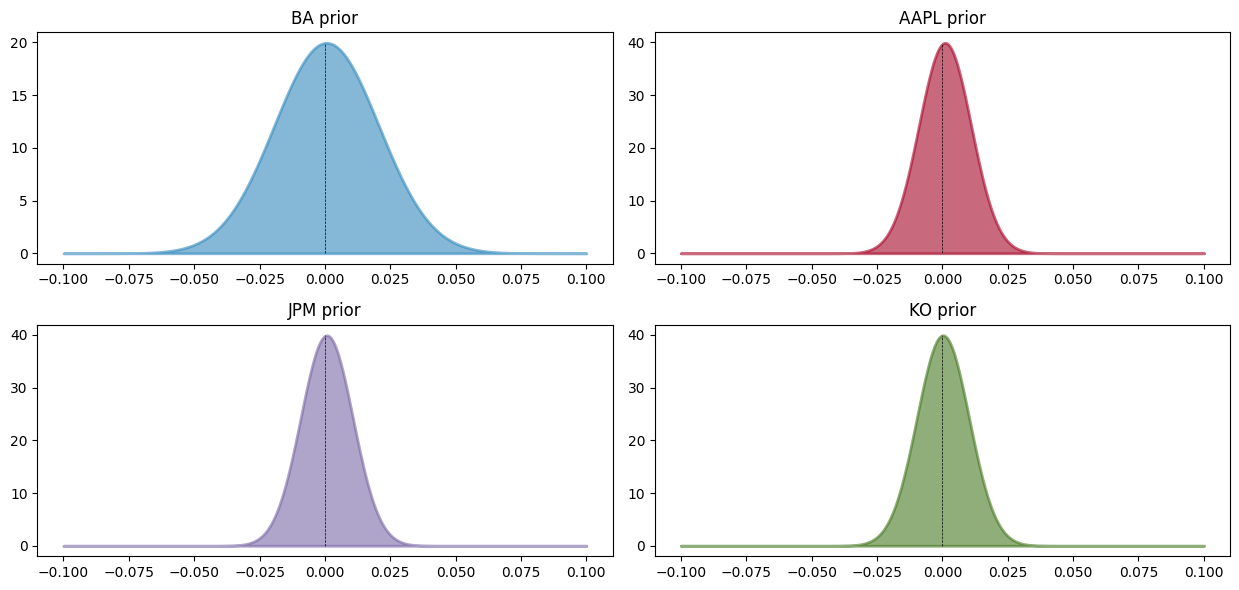

In [35]:
figsize(12.5,6)
normal = norm
x = np.linspace(-0.1, 0.1, 1000)

expert_prior_params = {"BA":(0.0006, 0.02),"AAPL":(0.001, 0.01),"JPM": (0.0007, 0.01),"KO": (0.0002, 0.01),}

for i, (name, params) in enumerate(expert_prior_params.items()):
    plt.subplot(2,2,i+1)
    y=normal.pdf(x,params[0],scale=params[1])
    plt.fill_between(x,0,y,color=colors[i],linewidth=2,edgecolor=colors[i],alpha=0.6)
    plt.title(name+" prior")
    plt.vlines(0,0,y.max(),"k","--",linewidth=0.5)
    plt.tight_layout()


In [36]:
import pymc as pm


prior_mu = np.array([x[0] for x in expert_prior_params.values()])
prior_std = np.array([x[1] for x in expert_prior_params.values()])

init = stock_returns.cov()

with pm.Model() as model:
    cov_matrix = pm.WishartBartlett("covariance", np.diag(prior_std**2), 10)
    mu = pm.Normal("returns", mu=prior_mu, sigma=1, shape=4)

Added new variable covariance_c to model diagonal of Wishart.
Added new variable covariance_z to model off-diagonals of Wishart.


In [44]:
with model:
    obs = pm.MvNormal("observed returns", mu=mu, cov=cov_matrix, observed=returns)
    step = pm.NUTS()
    trace = pm.sample(1000, step=step, chains=2)

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [chol_cov, returns]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

EOFError: 

In [70]:
import pymc as pm
import numpy as np
import arviz as az

# Example data (replace with your actual data)
expert_prior_params = {"BA":(0.0006, 0.02),"AAPL":(0.001, 0.01),"JPM": (0.0007, 0.01),"KO": (0.0002, 0.01),}


# Extract prior parameters
prior_mu = np.array([x[0] for x in expert_prior_params.values()])  # Prior means
prior_std = np.array([x[1] for x in expert_prior_params.values()])  # Prior standard deviations

# Initial covariance matrix (optional, can be used for initialization)
init_cov = np.diag(prior_std**2)

# Define the model
with pm.Model() as model:
    # Prior for the covariance matrix using LKJCholeskyCov
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov",
        n=len(prior_mu),  # Number of assets
        eta=2.0,  # Uniform correlation prior (eta=1 is uniform, eta>1 concentrates around identity)
        sd_dist=pm.HalfNormal.dist(sigma=prior_std),  # Prior for standard deviations
    )
    cov_matrix = pm.Deterministic("covariance", chol.dot(chol.T))  # Reconstruct covariance matrix

    # Prior for the mean returns
    mu = pm.Normal("returns", mu=prior_mu, sigma=prior_std, shape=len(prior_mu))

    # Likelihood (observed data)
    obs = pm.MvNormal("observed_returns", mu=mu, chol=chol, observed=returns)

    # Sampling
    trace = pm.sample(
        1000,  # Number of samples
        tune=1000,  # Number of tuning steps
        chains=2,  # Number of chains
        cores=1,  # Number of cores (set to 1 if running into parallelization issues)
        target_accept=0.9,  # Target acceptance rate for NUTS
        return_inferencedata=True,  # Return ArviZ InferenceData object
    )

# Inspect the results
az.summary(trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [chol_cov, returns]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 14 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
returns[0],-0.001,0.001,-0.003,0.002,0.000,0.000,1417.0,1759.0,1.0
returns[1],0.001,0.001,-0.001,0.002,0.000,0.000,1786.0,1557.0,1.0
returns[2],0.000,0.001,-0.001,0.002,0.000,0.000,1306.0,1481.0,1.0
returns[3],0.000,0.001,-0.001,0.001,0.000,0.000,1475.0,1494.0,1.0
chol_cov[0],0.038,0.001,0.037,0.040,0.000,0.000,1262.0,1311.0,1.0
chol_cov[1],0.010,0.001,0.009,0.012,0.000,0.000,1721.0,1329.0,1.0
chol_cov[2],0.021,0.001,0.020,0.022,0.000,0.000,2094.0,1604.0,1.0
chol_cov[3],0.015,0.001,0.014,0.017,0.000,0.000,1267.0,1423.0,1.0
chol_cov[4],0.005,0.001,0.004,0.006,0.000,0.000,2127.0,1656.0,1.0
chol_cov[5],0.017,0.000,0.017,0.018,0.000,0.000,2610.0,1555.0,1.0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:981: RuntimeWarning: divide by zero encountered in divide
  hist_dens = hist / (hist.sum() * np.diff(bin_edges))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:981: RuntimeWarning: invalid value encountered in divide
  hist_dens = hist / (hist.sum() * np.diff(bin_edges))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/stats/density_utils.py:700: RuntimeWarning: divide by zero encountered in divide
  f = grid_counts / bin_width / len(x)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arv

OverflowError: cannot convert float infinity to integer

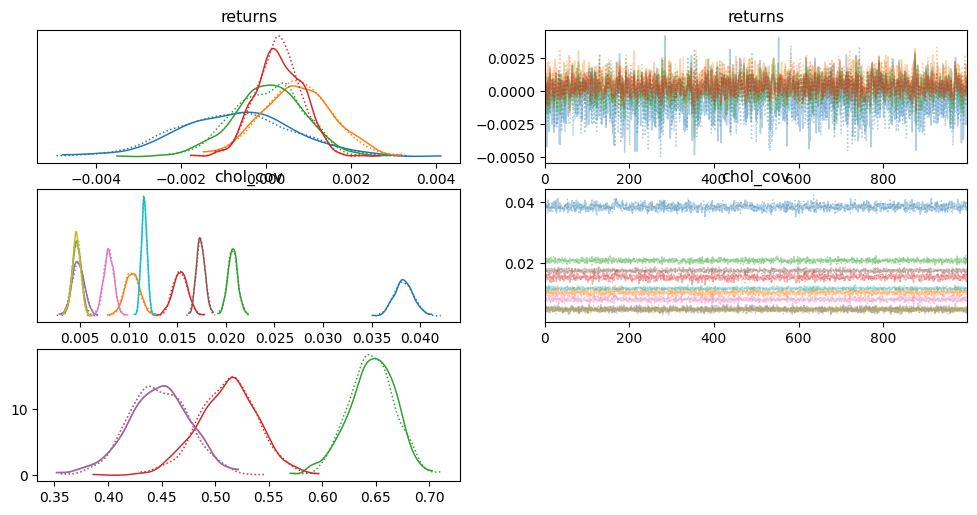

In [71]:
import arviz as az
az.plot_trace(trace)

In [75]:
## Get the posterior returns of the trace
data = trace.posterior["returns"]


In [76]:
data.shape

(2, 1000, 4)

/var/folders/qh/43yzjghs7pzb3lwh4m4rkxch0000gn/T/ipykernel_9853/2778328595.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


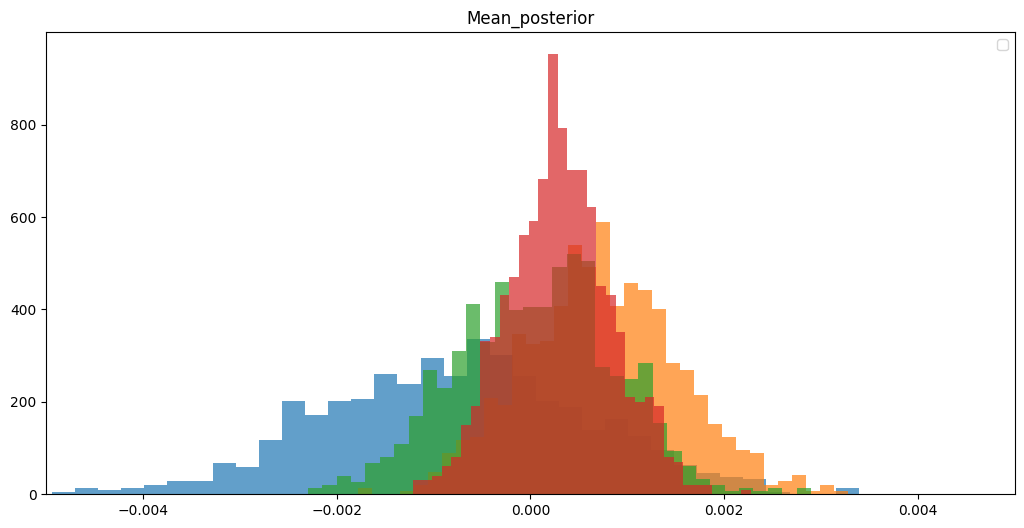

In [91]:
figsize(12.5,6)

mu_sample = data
### proivde colors for each stock

for i in range(4):
    plt.hist(mu_sample[1,:,i], bins=35, histtype="stepfilled", alpha=0.7, density=True)
    plt.title("Mean_posterior")
    plt.xlim(-0.005, 0.005)
    plt.legend()


In [46]:
import yfinance as yf
import pandas as pd

# Define the time period
start = '2020-01-01'
end = '2023-01-01'

# Fetch data for the stocks
stocks = {
    'BA': yf.download('BA', start, end),
    'AAPL': yf.download('AAPL', start, end),
    'JPM': yf.download('JPM', start, end),
    'KO': yf.download('KO', start, end),
}

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [48]:
# Calculate log returns for each stock
returns = pd.DataFrame()
for ticker, data in stocks.items():
    returns[ticker] = np.log(data['Close'] / data['Close'].shift(1))

# Drop the first row (NaN due to shift)
returns = returns.dropna()

In [49]:
# Convert returns to a NumPy array
returns_array = returns.to_numpy()

# Check the shape
print(returns_array.shape)  # Should be (n_samples, n_assets)

(755, 4)


In [50]:
import pymc as pm
import numpy as np
import arviz as az

# Extract prior parameters (example values, replace with your expert priors)
expert_prior_params = {
    'BA': (0.05, 0.1),
    'AAPL': (0.03, 0.08),
    'JPM': (0.04, 0.09),
    'KO': (0.06, 0.12),
}
prior_mu = np.array([x[0] for x in expert_prior_params.values()])  # Prior means
prior_std = np.array([x[1] for x in expert_prior_params.values()])  # Prior standard deviations

# Define the model
with pm.Model() as model:
    # Prior for the covariance matrix using LKJCholeskyCov
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol_cov",
        n=len(prior_mu),  # Number of assets
        eta=2.0,  # Uniform correlation prior
        sd_dist=pm.HalfNormal.dist(sigma=prior_std),  # Prior for standard deviations
    )
    cov_matrix = pm.Deterministic("covariance", chol.dot(chol.T))  # Reconstruct covariance matrix

    # Prior for the mean returns
    mu = pm.Normal("returns", mu=prior_mu, sigma=prior_std, shape=len(prior_mu))

    # Likelihood (observed data)
    obs = pm.MvNormal("observed_returns", mu=mu, chol=chol, observed=returns_array)

    # Sampling
    trace = pm.sample(
        1000,  # Number of samples
        tune=1000,  # Number of tuning steps
        chains=2,  # Number of chains
        cores=1,  # Number of cores
        target_accept=0.9,  # Target acceptance rate for NUTS
        return_inferencedata=True,  # Return ArviZ InferenceData object
    )

# Inspect the results
az.summary(trace)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [chol_cov, returns]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
returns[0],-0.001,0.001,-0.003,0.002,0.000,0.0,1224.0,1396.0,1.01
returns[1],0.001,0.001,-0.001,0.002,0.000,0.0,1344.0,1497.0,1.00
returns[2],0.000,0.001,-0.002,0.002,0.000,0.0,1067.0,1369.0,1.00
returns[3],0.000,0.001,-0.001,0.001,0.000,0.0,1272.0,1315.0,1.00
chol_cov[0],0.038,0.001,0.037,0.040,0.000,0.0,1860.0,1654.0,1.00
chol_cov[1],0.010,0.001,0.009,0.012,0.000,0.0,1998.0,1449.0,1.00
chol_cov[2],0.021,0.001,0.020,0.022,0.000,0.0,2858.0,1625.0,1.00
chol_cov[3],0.015,0.001,0.014,0.017,0.000,0.0,1675.0,1530.0,1.00
chol_cov[4],0.005,0.001,0.004,0.006,0.000,0.0,2424.0,1517.0,1.00
chol_cov[5],0.017,0.000,0.017,0.018,0.000,0.0,2891.0,1690.0,1.00


array([[<Axes: title={'center': 'returns'}>,
        <Axes: title={'center': 'returns'}>],
       [<Axes: title={'center': 'covariance'}>,
        <Axes: title={'center': 'covariance'}>]], dtype=object)

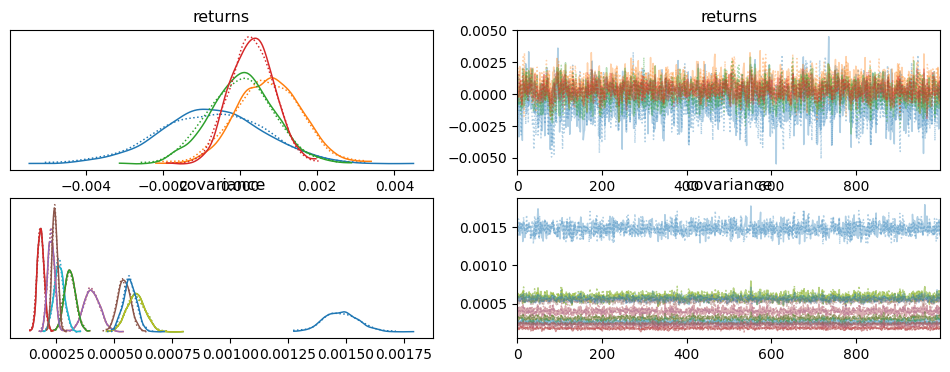

In [51]:
import arviz as az

# Plot traces
az.plot_trace(trace, var_names=["returns", "covariance"])

array([[<Axes: title={'center': 'returns'}>,
        <Axes: title={'center': 'returns'}>],
       [<Axes: title={'center': 'covariance'}>,
        <Axes: title={'center': 'covariance'}>]], dtype=object)

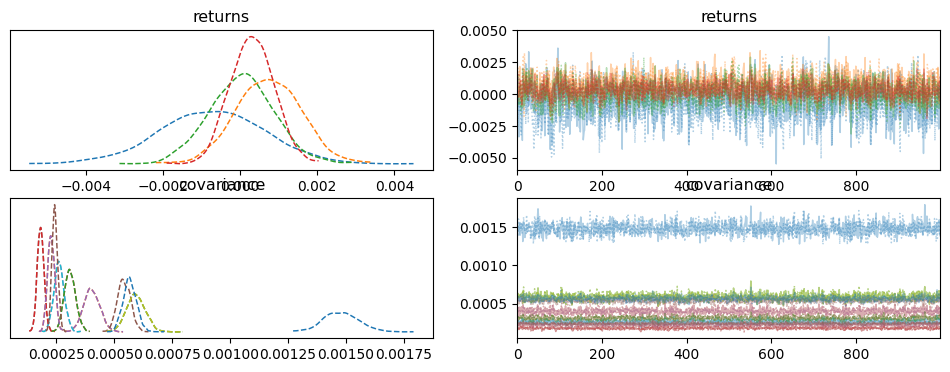

In [52]:
az.plot_trace(
    trace,
    var_names=["returns", "covariance"],
    compact=True,
    combined=True,
    divergences=True,
)

array([[<Axes: title={'center': 'returns'}>,
        <Axes: title={'center': 'returns'}>],
       [<Axes: title={'center': 'covariance'}>,
        <Axes: title={'center': 'covariance'}>]], dtype=object)

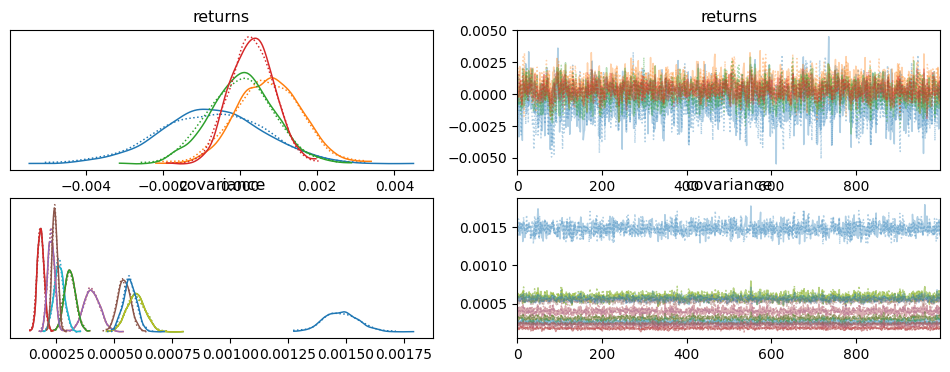

In [53]:
import matplotlib.pyplot as plt

# Plot traces
az.plot_trace(trace, var_names=["returns", "covariance"])


(array([[  3.7212428 ,   3.7212428 ,  18.60621401,  14.88497121,
          18.60621401,  33.49118522,  33.49118522,  74.42485604,
         119.07976966,  96.75231285, 145.12846928, 193.5046257 ,
         193.5046257 , 241.88078213, 226.99581092, 219.55332532,
         327.46936658, 282.81445295, 238.15953933, 212.11083971,
         204.66835411, 189.7833829 , 160.01344049, 115.35852686,
          93.03107005,  66.98237044,  66.98237044,  40.93367082,
          29.76994242,  26.04869961,  11.16372841,   0.        ,
           3.7212428 ,  11.16372841,   3.7212428 ],
        [  3.7212428 ,   7.4424856 ,   3.7212428 ,  18.60621401,
          22.32745681,  26.04869961,  55.81864203,  66.98237044,
          93.03107005, 148.84971208, 253.04451054, 245.60202493,
         271.65072455, 357.23930899, 308.86315257, 297.69942416,
         282.81445295, 353.51806619, 271.65072455, 189.7833829 ,
         137.68598367, 133.96474087,  66.98237044,  33.49118522,
          40.93367082,  14.88497121,  

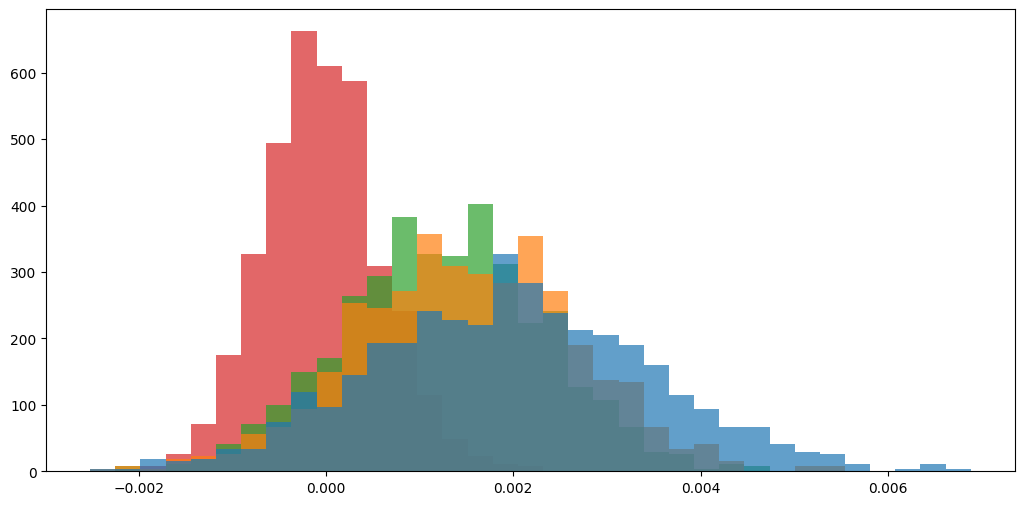

In [66]:
plt.hist(mu_sample[1,:], bins=35, histtype="stepfilled",alpha=0.7, density=True, label=['BA', 'AAPL','JPM','KO'])

In [56]:
## Get the covariance matrix of the trace
cov_sample = trace.posterior["covariance"]
cov_sample.shape

(2, 1000, 4, 4)

In [57]:
# Nombres de los activos correspondientes a cada variable
asset_names = ["Boeing", "Apple", "JPMorgan", "CocaCola"]


In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Obtener la matriz de covarianza promedio
cov_mean = np.mean(cov_sample, axis=(0, 1))

# Verificar la forma de la matriz de covarianza promedio
print(cov_mean.shape)


(4, 4)


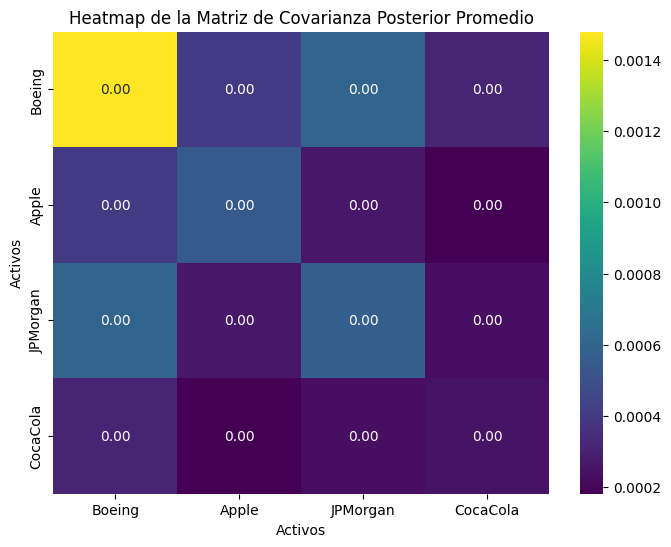

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un heatmap de la matriz de covarianza promedio
plt.figure(figsize=(8, 6))
sns.heatmap(cov_mean, annot=True, fmt=".2f", cmap="viridis", cbar=True,
            xticklabels=asset_names, yticklabels=asset_names)

# Añadir etiquetas y un título
plt.title("Heatmap de la Matriz de Covarianza Posterior Promedio")
plt.xlabel("Activos")
plt.ylabel("Activos")

# Mostrar la gráfica
plt.show()


In [60]:
# Acceder a las muestras de la matriz de covarianza desde la traza
cov_sample = trace.posterior["covariance"]

# Definir n_dim basado en la forma de la matriz de covarianza
n_dim = cov_sample.shape[-1]  # Última dimensión de la matriz de covarianza

# Función para convertir una matriz de covarianza en una matriz de correlación
def cov_to_corr(cov_matrix):
    stddev = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(stddev, stddev)
    return corr_matrix

# Aplicar la función a cada muestra de la matriz de covarianza
corr_samples = np.array([cov_to_corr(cov) for cov in cov_sample.values.reshape(-1, n_dim, n_dim)])

# Calcular la matriz de correlación promedio
corr_mean = np.mean(corr_samples, axis=0)

# Verificar la forma de la matriz de correlación promedio
print(corr_mean.shape)


(4, 4)


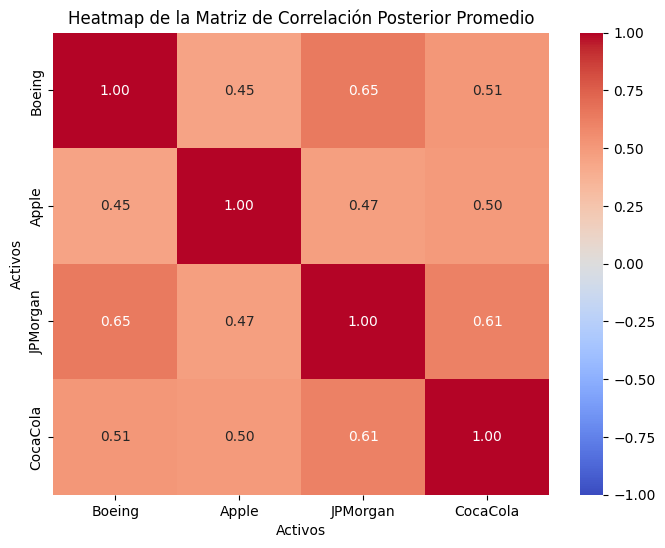

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Nombres de los activos correspondientes a cada variable
asset_names = ["Boeing", "Apple", "JPMorgan", "CocaCola"]

# Crear un heatmap de la matriz de correlación promedio
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mean, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            xticklabels=asset_names, yticklabels=asset_names, vmin=-1, vmax=1)

# Añadir etiquetas y un título
plt.title("Heatmap de la Matriz de Correlación Posterior Promedio")
plt.xlabel("Activos")
plt.ylabel("Activos")

# Mostrar la gráfica
plt.show()


In [95]:
import numpy as np
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

# Simulación de datos de una distribución normal multivariada
np.random.seed(42)
n_dim = 4  # Número de dimensiones
n_samples = 100  # Número de muestras

# Verdadero vector de medias
true_mu = np.array([0.5, 1.0, -0.5, 2.0])

# Verdadera matriz de covarianza
true_cov = np.array([[1.0, 0.8, 0.3, 0.2],
                     [0.8, 1.5, 0.4, 0.1],
                     [0.3, 0.4, 1.0, 0.6],
                     [0.2, 0.1, 0.6, 1.2]])

# Simular datos
data = np.random.multivariate_normal(true_mu, true_cov, size=n_samples)

# Definir los parámetros previos
prior_mu = np.array([0.5, 1.0, -0.5, 2.0])
prior_std = np.array([1.0, 1.0, 1.0, 1.0])

with pm.Model() as model:
    # Definir la matriz de covarianza utilizando WishartBartlett
    cov_matrix = pm.WishartBartlett("covariance", S=np.diag(prior_std**2) + 0.1, nu=n_dim + 2)
    
    # Definir la media con una distribución normal
    mu = pm.Normal("theta", mu=prior_mu, sigma=2, shape=n_dim)
    
    # Likelihood para los datos observados
    obs = pm.MvNormal("observed", mu=mu, cov=cov_matrix, observed=data)
    
    # Muestra de la distribución posterior utilizando el muestreador NUTS
    trace = pm.sample(5000, tune=1000)

    

# Resumen de la traza
az.summary(trace)

# Visualizar las trazas
az.plot_trace(trace)
plt.show()

# Visualizar la matriz de covarianza posterior promedio
cov_mean = np.mean(trace.posterior["covariance"], axis=(0, 1))

# Crear un heatmap de la matriz de covarianza posterior promedio
plt.figure(figsize=(8, 6))
sns.heatmap(cov_mean, annot=True, fmt=".2f", cmap="viridis", cbar=True)
plt.title("Heatmap de la Matriz de Covarianza Posterior Promedio")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.show()


Added new variable covariance_c to model diagonal of Wishart.


Added new variable covariance_z to model off-diagonals of Wishart.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [covariance_c, covariance_z, theta]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

EOFError: 

In [31]:
# Función para convertir una matriz de covarianza a una matriz de correlación
def cov_to_corr(cov_matrix):
    stddev = np.sqrt(np.diag(cov_matrix))
    corr_matrix = cov_matrix / np.outer(stddev, stddev)
    return corr_matrix

# Obtener la matriz de covarianza posterior promedio
cov_mean = np.mean(trace.posterior["covariance"], axis=(0, 1))

# Convertir la matriz de covarianza promedio a una matriz de correlación
corr_mean = cov_to_corr(cov_mean)


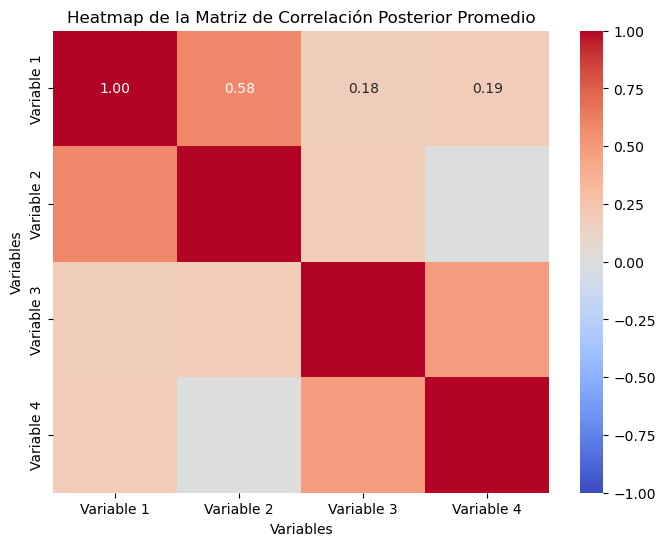

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Nombres de las variables (puedes ajustar según corresponda)
asset_names = ["Variable 1", "Variable 2", "Variable 3", "Variable 4"]

# Crear un heatmap de la matriz de correlación promedio
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mean, annot=True, fmt=".2f", cmap="coolwarm", cbar=True,
            xticklabels=asset_names, yticklabels=asset_names, vmin=-1, vmax=1)

# Añadir etiquetas y un título
plt.title("Heatmap de la Matriz de Correlación Posterior Promedio")
plt.xlabel("Variables")
plt.ylabel("Variables")

# Mostrar la gráfica
plt.show()
